# Exploratory Data Analysis 

**Goal**: Understand the structure, patterns, and anomalies in the electricity
price and weather data before modelling. Identify which features
are most likely to be useful predictors.

1. Price over time: visualize the energy crisis 2021–2022
2. Price distribution: identify negative prices and extreme outliers
4. General distribution and distrubition by year: show crisis impact and recovery
5. Price by hour: intraday demand patterns
6. Heatmap: average price by hour and month combined
7. Weekend vs weekday comparison
8. Feature correlation with price
9. Showing the upcoming split visually

**Key findings**
- 2022 crisis pushed median prices to ~€200/MWh -> 5x normal levels
- Negative prices occur during renewable oversupply, more frequent post-2023
- Wind power has the strongest negative correlation with price among weather features
- Spring midday is cheapest (solar + mild weather), late summer evening is most expensive
- Weekday prices are meaningfully higher than weekend prices

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("df_final.csv", index_col="date", parse_dates=True)

## Price over time / Energy crisis

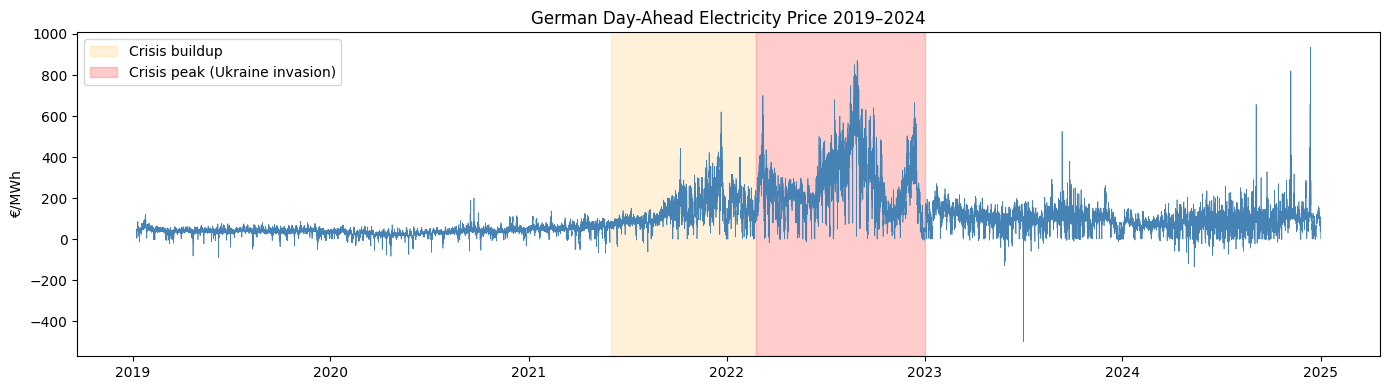

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(df["price_eur_mwh"], linewidth=0.5, color="steelblue")

# Crisis buildup: prices start rising after Russia reduces gas supply
plt.axvspan("2021-06-01", "2022-02-23", alpha=0.15, color="orange", label="Crisis buildup")

# Crisis peak: Russia invades Ukraine, prices hit record >€200/MWh
plt.axvspan("2022-02-24", "2023-01-01", alpha=0.2, color="red", label="Crisis peak (Ukraine invasion)")

plt.title("German Day-Ahead Electricity Price 2019–2024")
plt.ylabel("€/MWh")
plt.legend()
plt.tight_layout()
plt.show()

## Price distribution

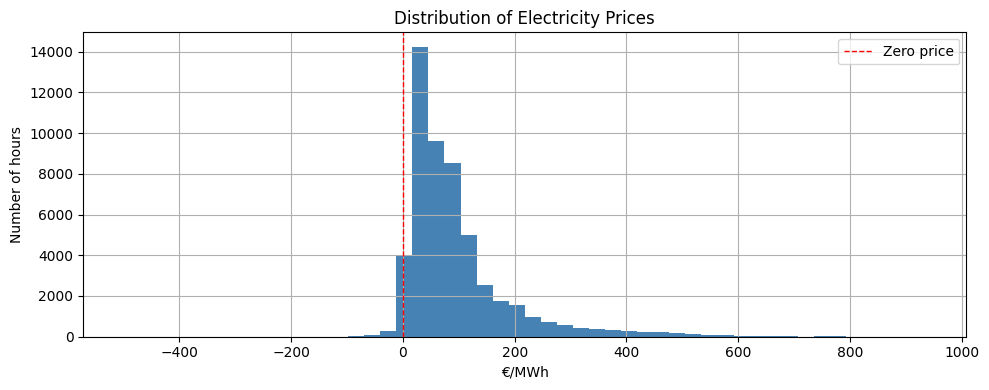

Negative price hours: 1452 (2.8% of all hours)


In [3]:
plt.figure(figsize=(10, 4))
df["price_eur_mwh"].hist(bins=50, color="steelblue", edgecolor="none")
plt.axvline(0, color="red", linewidth=1, linestyle="--", label="Zero price")
plt.title("Distribution of Electricity Prices")
plt.xlabel("€/MWh")
plt.ylabel("Number of hours")
plt.legend()
plt.tight_layout()
plt.show()

negative = (df["price_eur_mwh"] < 0).sum()
print(f"Negative price hours: {negative} ({100*negative/len(df):.1f}% of all hours)")

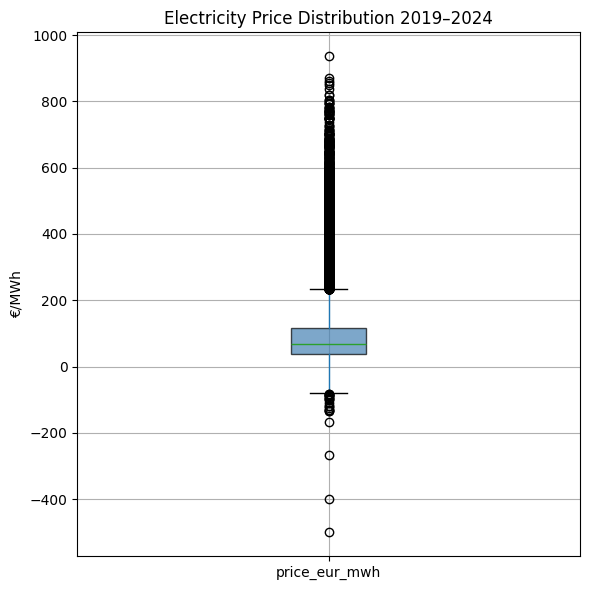

In [4]:
plt.figure(figsize=(6, 6))
df.boxplot(column="price_eur_mwh",
           patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.7))
plt.title("Electricity Price Distribution 2019–2024")
plt.ylabel("€/MWh")
plt.tight_layout()
plt.show()

In [5]:
df["year"] = df.index.year

<Figure size 1000x500 with 0 Axes>

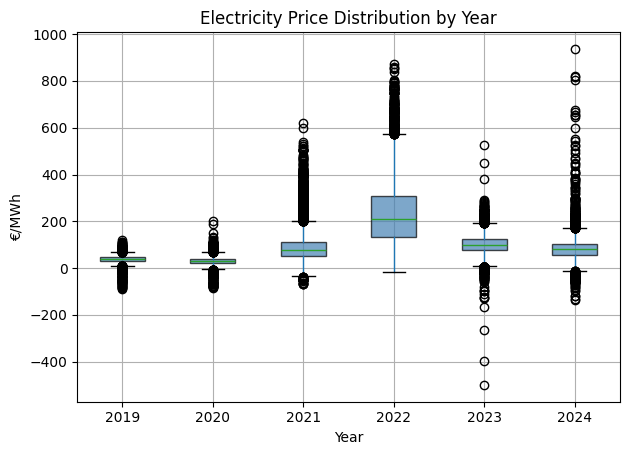

In [6]:
plt.figure(figsize=(10, 5))
df.boxplot(column="price_eur_mwh", by="year", 
           patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.7))
plt.suptitle("")
plt.title("Electricity Price Distribution by Year")
plt.xlabel("Year")
plt.ylabel("€/MWh")
plt.tight_layout()
plt.show()

**2019-2020 Normal market**:
Prices tight and low, median around €35–40/MWh. Small spread, few outliers.
This is what a healthy competitive electricity market looks like.

**2020 COVID effect**:
Slightly lower than 2019 — lockdowns reduced industrial demand, pushing prices down.

**2021 Crisis begins**:
Box starts rising and widening significantly. Russia begins reducing gas flows to Europe,
prices become more volatile and unpredictable. Outliers appear above €400/MWh.

**2022 Crisis peak**:
The box explodes. Median jumps to ~€200/MWh — roughly 5x normal levels.
Extreme outliers reach €800+/MWh. This is the direct effect of the Ukraine invasion
and gas supply cuts. 

**2023 Recovery begins**:
Box shrinks back dramatically. Median returns to ~€100/MWh.
Notable: **negative price outliers appear**, going as low as -€400/MWh.
Germany rapidly expanded renewables to replace gas, causing frequent oversupply episodes
where supply exceeded demand and prices turned negative.

**2024 New normal**:
Similar to 2023 but slightly lower median. Market stabilizing but prices remain
above pre-crisis levels. Negative price outliers persist - more renewables means
more frequent oversupply events.

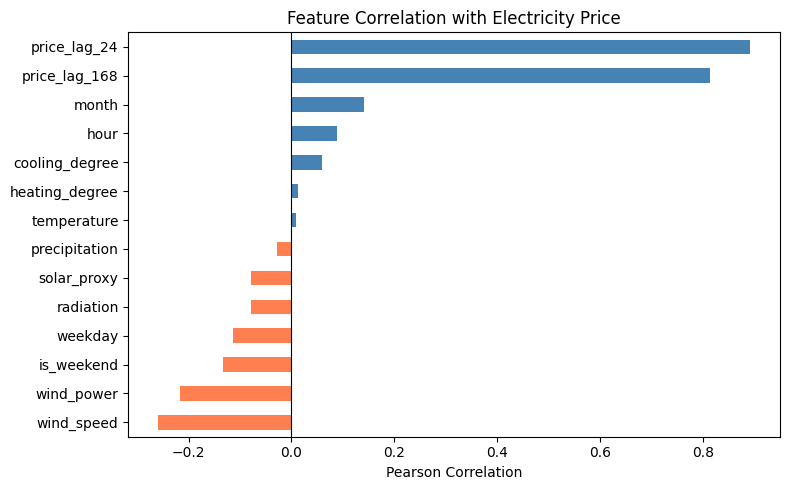

In [12]:
# Drop year, since it captures crisis trend, not a real weather/time predictor
df = df.drop(columns=["year"])
plt.figure(figsize=(8, 5))
corr = df.corr()["price_eur_mwh"].drop("price_eur_mwh").sort_values()
colors = ["coral" if c < 0 else "steelblue" for c in corr]
corr.plot(kind="barh", color=colors, edgecolor="none")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature Correlation with Electricity Price")
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

Add # and restart kernel to undo year drop. 
Not dropping month, cause it correlates with price because of genuine recurring seasonal patterns that repeat every year:
- January is cold every year → heating demand → higher price
- July is hot every year → cooling demand → higher price
- Spring and autumn are mild every year → lower demand → lower price

## Average price by hour

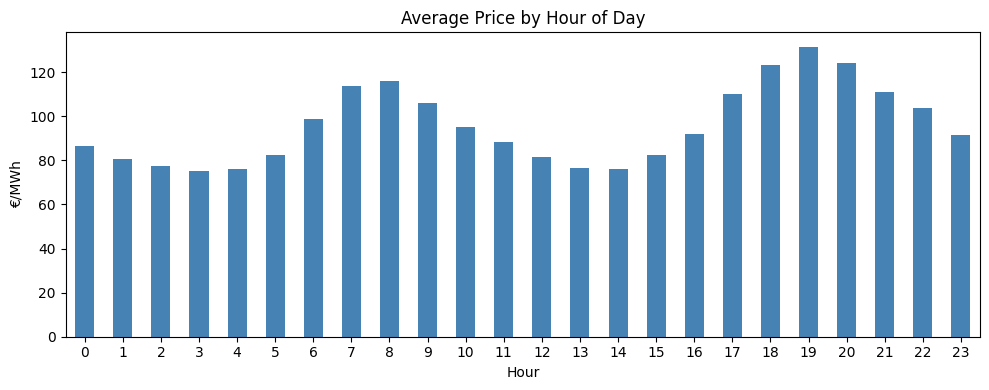

In [8]:
plt.figure(figsize=(10, 4))
df.groupby("hour")["price_eur_mwh"].mean().plot(kind="bar", color="steelblue", edgecolor="none")
plt.title("Average Price by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("€/MWh")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Heatmap of avg price by hour and month 

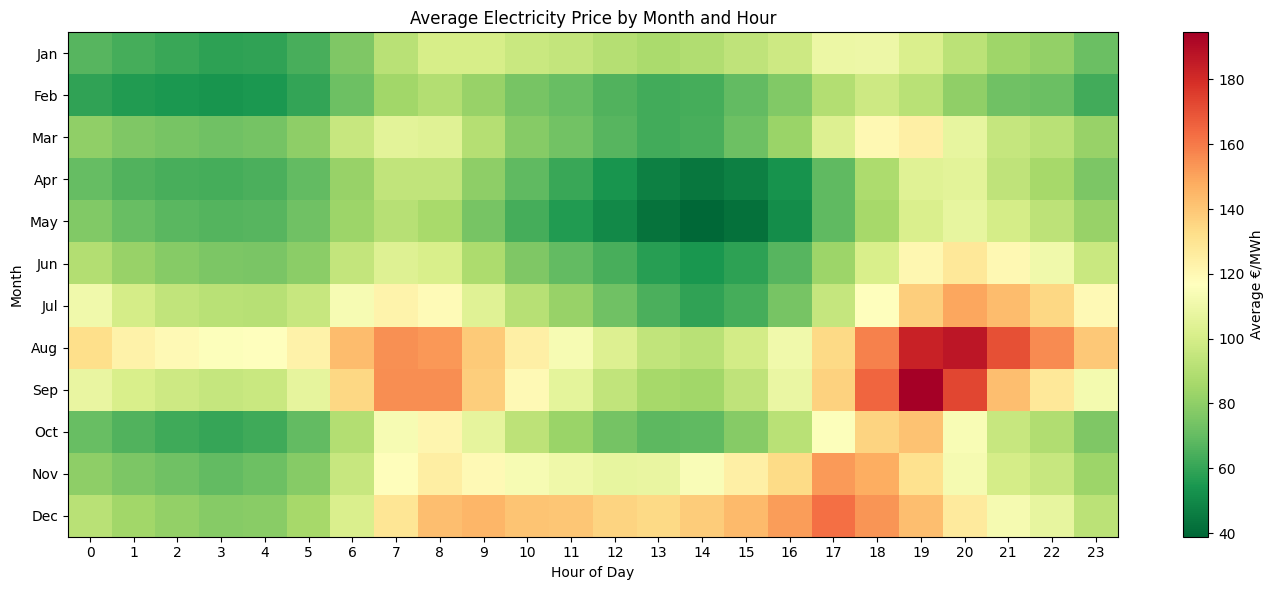

In [9]:
import matplotlib.pyplot as plt
import numpy as np

pivot = df.groupby(["month", "hour"])["price_eur_mwh"].mean().unstack()

plt.figure(figsize=(14, 6))
plt.imshow(pivot, aspect="auto", cmap="RdYlGn_r")
plt.colorbar(label="Average €/MWh")
plt.title("Average Electricity Price by Month and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Month")
plt.xticks(range(24), range(24))
plt.yticks(range(12), ["Jan","Feb","Mar","Apr","May","Jun",
                        "Jul","Aug","Sep","Oct","Nov","Dec"])
plt.tight_layout()
plt.show()

**The dark green block (Apr-Jun, hours 10-15) -> cheapest electricity**
Spring midday is the cheapest time of year. Why? Long sunny days mean maximum solar generation, mild temperatures mean low heating/cooling demand, and spring is often windy in Germany. All three factors push price down simultaneously.

**The red/orange block (Aug-Sep, hours 18-20) -> most expensive**
Late summer evenings are the most expensive. Why? Solar panels stop generating after sunset, but people come home from work and turn on appliances, cooking, heating water. Demand peaks exactly when solar disappears. August and September are also historically when gas storage was lowest during the crisis years, which amplifies the effect.


- Hours 0–5 -> cheap everywhere, everyone is sleeping
- Hours 6–9 -> prices rise as industry and offices start
- Hours 10–15 ->  drops in spring/summer due to solar
- Hours 17–21 -> evening peak, solar gone, demand high
- Hours 22–23 -> drops again as activity winds down

## Weekend vs Weekday

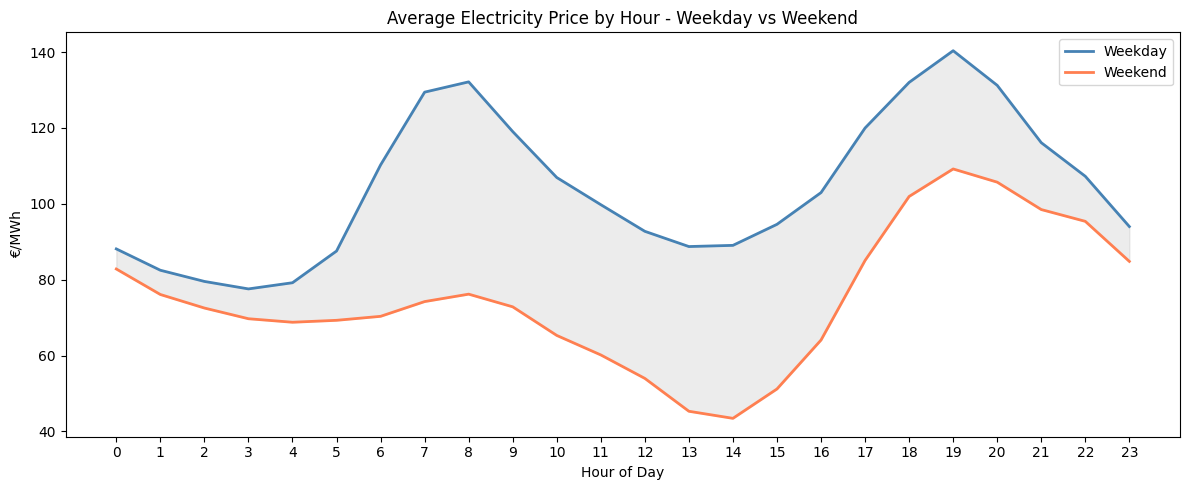

Average weekday price: €104.2/MWh
Average weekend price: €74.9/MWh
Average difference: €29.3/MWh


In [10]:
plt.figure(figsize=(12, 5))

pivot_weekday = df[df["is_weekend"]==0].groupby("hour")["price_eur_mwh"].mean()
pivot_weekend = df[df["is_weekend"]==1].groupby("hour")["price_eur_mwh"].mean()

plt.plot(pivot_weekday, color="steelblue", linewidth=2, label="Weekday")
plt.plot(pivot_weekend, color="coral", linewidth=2, label="Weekend")
plt.fill_between(pivot_weekday.index, pivot_weekday, pivot_weekend, alpha=0.15, color="gray")
plt.title("Average Electricity Price by Hour - Weekday vs Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("€/MWh")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

diff = (pivot_weekday - pivot_weekend).mean()
print(f"Average weekday price: €{pivot_weekday.mean():.1f}/MWh")
print(f"Average weekend price: €{pivot_weekend.mean():.1f}/MWh")
print(f"Average difference: €{diff:.1f}/MWh")

The shaded area between the lines shows exactly when and how much weekdays are more expensive than weekends. The morning peak (7–9am) is much stronger on weekdays when industry starts up.

## Train-Val-Test Split Visualisation

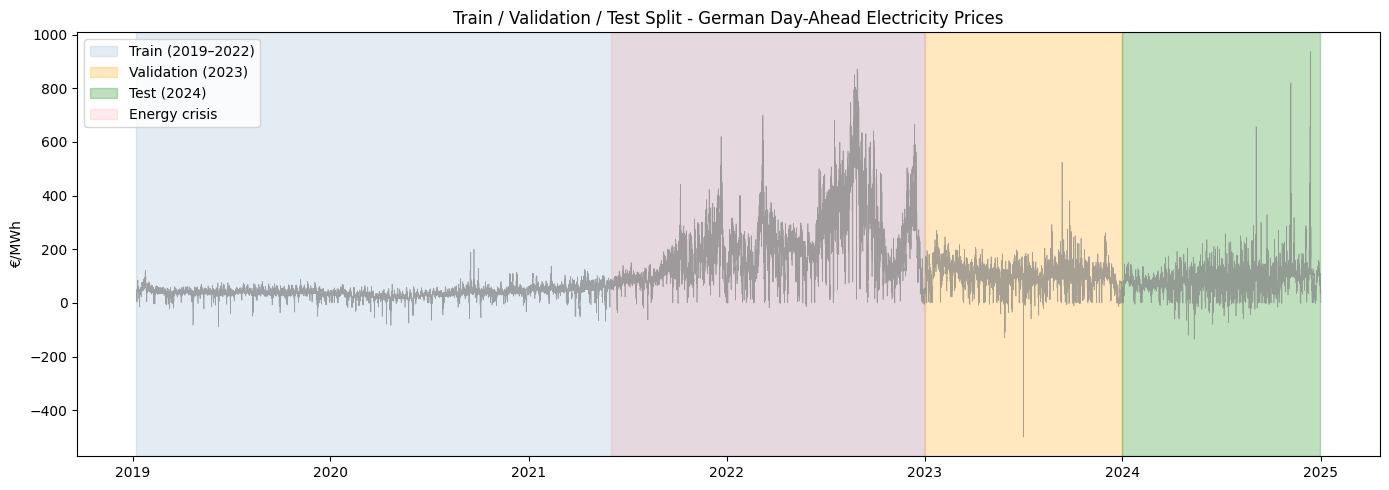

In [11]:
plt.figure(figsize=(14, 5))


plt.plot(df["price_eur_mwh"], linewidth=0.5, color="gray", alpha=0.7)


plt.axvspan("2019-01-08", "2022-12-31", alpha=0.15, color="steelblue", label="Train (2019–2022)")
plt.axvspan("2023-01-01", "2023-12-31", alpha=0.25, color="orange",   label="Validation (2023)")
plt.axvspan("2024-01-01", "2024-12-31", alpha=0.25, color="green",    label="Test (2024)")


plt.axvspan("2021-06-01", "2023-01-01", alpha=0.08, color="red", label="Energy crisis")

plt.title("Train / Validation / Test Split - German Day-Ahead Electricity Prices")
plt.ylabel("€/MWh")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()